# 03 Validate and Visualize

This notebook checks that generated molecules look chemically reasonable before exporting them.

The checks here are not a full scientific validation. They are practical checks for common mistakes: wrong repeat count, missing stereochemistry, unexpected side-chain length, or a structure that fails to display.

## Step 1: Build molecules to inspect

The default set is PHB4, PHO4, and PHDD4. These are small enough for quick inspection.

In [1]:
import pandas as pd
from rdkit.Chem import Draw

from iphasimulator.workflows import build_validation_molecules, describe_molecules

molecules = build_validation_molecules()
list(molecules)

['PHB4_R', 'PHO4_R', 'PHDD4_R']

## Step 2: Inspect the text summary

`atoms` is the RDKit heavy-atom count before hydrogens are added for 3D export. `chiral_centres` should show one R centre per repeat unit for the default molecules.

In [2]:
summary = pd.DataFrame(describe_molecules(molecules))
summary

,name,atoms,smiles,chiral_centres
0,PHB4_R,25,C[C@H](CC(=O)O)OC(=O)C[C@@H](C)OC(=O)C[C@@H](C...,"[(1, R), (7, R), (13, R), (19, R)]"
1,PHO4_R,41,CCCCC[C@@H](O)CC(=O)O[C@H](CCCCC)CC(=O)O[C@H](...,"[(1, R), (11, R), (21, R), (31, R)]"
2,PHDD4_R,57,CCCCCCCCC[C@@H](O)CC(=O)O[C@H](CCCCCCCCC)CC(=O...,"[(1, R), (15, R), (29, R), (43, R)]"


## Step 3: Inspect the drawings

Use these drawings to check the chain length and side-chain size visually. For long chains, the drawing is a compact 2D representation, not a realistic folded 3D conformation.

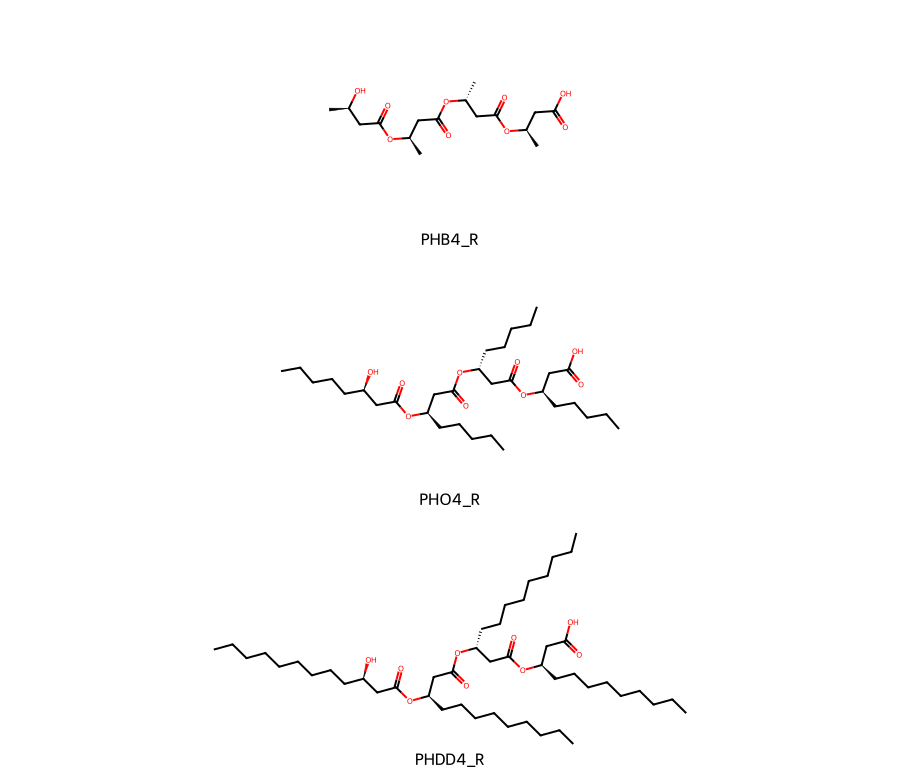

In [3]:
Draw.MolsToGridImage(
    list(molecules.values()),
    molsPerRow=1,
    subImgSize=(900, 260),
    legends=list(molecules.keys()),
)